# 🛍️ Customer Segmentation Using Clustering – Unsupervised Learning

This notebook applies unsupervised machine learning to segment customers based on their purchasing patterns, recency, and average unit cost.

The project was developed as part of the **University of Cambridge Data Science Career Accelerator** and is aimed at enabling **targeted marketing** and **customer retention strategies** for retail/e-commerce businesses.

---

### 📊 Project Highlights

- Identified 3 core customer segments using K-Means and hierarchical clustering
- Used CLV, purchase frequency, and recency as key segmentation features
- Validated optimal `k` using elbow and silhouette methods
- Recommended segment-specific marketing, product, and engagement strategies

---

> Skip to the "Cluster Insights" and "Strategic Recommendations" sections for key business takeaways.


### Imports and Data loading

In [2]:
%pip install -q gdown pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
!gdown 'https://drive.google.com/uc?export=download&id=1S5wniOV5_5htDfUFeZhlCLibvtihNLKK' -O data/

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1S5wniOV5_5htDfUFeZhlCLibvtihNLKK
From (redirected): https://drive.google.com/uc?export=download&id=1S5wniOV5_5htDfUFeZhlCLibvtihNLKK&confirm=t&uuid=87b0c5e1-b5bf-4f61-a3d6-acb8337d4c4f
To: /Users/prash/workspace/data-science-portfolio/customer-segmentation/data/CUSTOMERS_CLEAN.csv
100%|████████████████████████████████████████| 191M/191M [00:03<00:00, 56.8MB/s]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, timedelta
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples

In [6]:
# for wide print without line wrap
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_colwidth", None)

In [7]:
df = pd.read_csv("./data/CUSTOMERS_CLEAN.csv")

### EDA

In [8]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951669 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Quantity              951669 non-null  int64 
 1   City                  951534 non-null  object
 2   Continent             951669 non-null  object
 3   Postal_Code           947953 non-null  object
 4   State_Province        834477 non-null  object
 5   Order_Date            951669 non-null  object
 6   Delivery_Date         951669 non-null  object
 7   Total Revenue         951669 non-null  object
 8   Unit Cost             951669 non-null  object
 9   Discount              951669 non-null  object
 10  OrderTypeLabel        951669 non-null  object
 11  CustomerCountryLabel  951669 non-null  object
 12  Customer_BirthDate    951669 non-null  object
 13  Customer_Group        951669 non-null  object
 14  Customer_Type         951669 non-null  object
 15  Order ID         

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


In [ ]:
# identify any missing values
df.isnull().sum()

Quantity                     0
City                       135
Continent                    0
Postal_Code               3716
State_Province          117192
Order_Date                   0
Delivery_Date                0
Total Revenue                0
Unit Cost                    0
Discount                     0
OrderTypeLabel               0
CustomerCountryLabel         0
Customer_BirthDate           0
Customer_Group               0
Customer_Type                0
Order ID                     0
Profit                       0
Days to Delivery             0
Loyalty Num                  0
Customer ID                  0
dtype: int64

In [ ]:
# identify duplicates
print(
    "Total number of duplicate rows based on all columns:\n",
    len(df[df.duplicated(keep=False)]),
)

# Drop duplicates in place
df.drop_duplicates(keep=False, inplace=True)

Total number of duplicate rows based on all columns:
 42


The Age feature shows significant anomalies. Upon closer examination of the Order_Date column, we've identified a substantial number of orders apparently placed by individuals under 18 years old. Given that standard e-commerce Terms & Conditions typically restrict purchases to those 18 and older, we can reasonably conclude this is a data quality issue rather than genuine underage purchasing. To improve our analysis accuracy, we propose removing these outliers from the dataset.

In [ ]:
def filter_minor_orders(df):
    df_age_filtered = df.copy()

    # Convert Order_Date and Customer_BirthDate to datetime
    df_age_filtered["Order_Date"] = pd.to_datetime(
        df_age_filtered["Order_Date"], format="%d%b%Y"
    )
    df_age_filtered["Customer_BirthDate"] = pd.to_datetime(
        df_age_filtered["Customer_BirthDate"], format="%d%b%Y"
    )

    # Calculate age at time of order
    df_age_filtered["Age_at_Order"] = (
        (df_age_filtered["Order_Date"] - df_age_filtered["Customer_BirthDate"]).dt.days
        / 365.25
    ).astype(int)

    # Filter out online orders where customer was under 18
    df_filtered = df_age_filtered[
        (df_age_filtered["Age_at_Order"] >= 18)
        | (df_age_filtered["OrderTypeLabel"] == "Retail Sale")
    ]

    # Identify minor orders that were removed (online orders by minors)
    df_minor_orders = df_age_filtered[
        (df_age_filtered["Age_at_Order"] < 18)
        & (df_age_filtered["OrderTypeLabel"] == "Retail Sale")
    ]

    print("Minor orders that were removed:")
    print(df_minor_orders)

    # Count removed orders
    removed_orders = len(df_age_filtered) - len(df_filtered)

    print(f"Removed {removed_orders} orders placed by minors.")

    return df_filtered


# Apply the filter to our aggregated dataframe
df = filter_minor_orders(df)

Minor orders that were removed:
        Quantity       City Continent Postal_Code         State_Province Order_Date Delivery_Date Total Revenue Unit Cost Discount OrderTypeLabel CustomerCountryLabel Customer_BirthDate           Customer_Group                            Customer_Type    Order ID   Profit  Days to Delivery  Loyalty Num  Customer ID  Age_at_Order
47             2  Mundaring   Oceania        6073      Western Australia 2012-01-02     02JAN2012       $44.00    $18.20         .    Retail Sale            Australia         1995-10-09  Orion Club Gold members    Orion Club Gold members high activity  1230005769   $7.60                  0            0         2351            16
63             2  Liverpool   Oceania         217        New South Wales 2012-01-02     02JAN2012       $66.00    $33.20         .    Retail Sale            Australia         1997-02-16  Orion Club Gold members    Orion Club Gold members high activity  1230005983  ($0.40)                 0           99   

### Feature engineering

In [ ]:
# Create new features
def feature_engineer(data):
    df = data.copy()
    # For the cost columns remove the dollar sign, comma, trialing spaces and convert to float
    df["Total Revenue"] = (
        df["Total Revenue"]
        .apply(lambda x: x.strip("$ ").replace(",", ""))
        .astype(float)
    )
    df.rename(columns={"Total Revenue": "CLV"}, inplace=True)

    df["Unit Cost"] = (
        df["Unit Cost"].apply(lambda x: x.strip("$ ").replace(",", "")).astype(float)
    )
    df.rename(columns={"Unit Cost": "Avg_Unit_Cost"}, inplace=True)

    # how often a customer purchases
    df["Frequency"] = df.groupby("Customer ID")["Order ID"].transform("count")

    # Calculate recency (time since last order)
    df["Recency"] = (
        pd.to_datetime("today") - pd.to_datetime(df["Delivery_Date"], format="%d%b%Y")
    ).dt.days

    # Calculate age
    df["DOB"] = pd.to_datetime(df["Customer_BirthDate"], format="%d%b%Y")
    df["Age"] = (
        (pd.to_datetime("today") - pd.to_datetime(df["DOB"])).dt.days // 365.2425
    ).astype(int)

    return df

In [ ]:
df = feature_engineer(df)

In [ ]:
# Creating one row per Customer ID by aggregating on key features
# CLV - total value
# Avg_Unit_Cost - max value
# Frequency - last one
# Recency - Max value
# Age - last one

df_aggr = (
    df.groupby(["Customer ID"])
    .agg(
        {
            "CLV": "sum",
            "Avg_Unit_Cost": "mean",
            "Frequency": "last",
            "Recency": "min",
            "Age": "first",
        }
    )
    .reset_index()
)

In [ ]:
# verifying the aggregated data
print(df_aggr.shape)
print(df_aggr.head())

(67766, 6)
   Customer ID      CLV  Avg_Unit_Cost  Frequency  Recency  Age
0            1  4322.70      89.622857         35     2817   70
1            3  2821.00      90.505000         20     2919   41
2            4   782.67      37.195556          9     3908   41
3            5  2810.98     107.947368         19     2805   36
4            6  1604.58      52.526667         15     2990   65


In [ ]:
# Generic outlier identifying and handling methods


#  Identify outliers using IQR method
def identify_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


# Print outlier information for features
def print_outliers(df, columns):
    for col in columns:
        outliers = identify_outliers(df, col)
        if len(outliers) > 0:
            print(f"Column: {col}")
            print(f"Number of outliers: {len(outliers)}")
            print(f"Percentage of outliers: {(len(outliers) / len(df)) * 100:.2f}%")
            print("-------------------------")


# Handle the outliers with IQR method
def apply_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


def apply_winsorize(df, column, percentile):
    lower = df[column].quantile(percentile)
    upper = df[column].quantile(1 - percentile)
    return df[column].clip(lower, upper)


def apply_log_transform(df, column):
    return np.log1p(df[column])


def handle_outliers(df, columns, method="winsorize", percentile=0.05):
    df_cleaned = df.copy()
    for column in columns:
        if method == "iqr":
            df_cleaned[column] = apply_iqr(df, column)
        elif method == "winsorize":
            df_cleaned[column] = apply_winsorize(df, column, percentile)
        elif method == "log_transform":
            df_cleaned[column] = apply_log_transform(df, column)
        else:
            return df_cleaned[column]
    return df_cleaned

In [ ]:
numeric_columns = [
    col
    for col in df_aggr.select_dtypes(include=[np.number]).columns
    if col != "Customer ID"
]
print_outliers(df_aggr, numeric_columns)

Column: CLV
Number of outliers: 2576
Percentage of outliers: 3.80%
-------------------------
Column: Avg_Unit_Cost
Number of outliers: 2875
Percentage of outliers: 4.24%
-------------------------
Column: Frequency
Number of outliers: 2555
Percentage of outliers: 3.77%
-------------------------
Column: Recency
Number of outliers: 3442
Percentage of outliers: 5.08%
-------------------------


In [ ]:
def visualize_key_features(df_aggr):

    # Create a 2x3 subplot
    fig, axes = plt.subplots(2, 3, figsize=(20, 15))

    # 1. Distribution of CLV
    sns.histplot(data=df_aggr, x="CLV", kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Distribution of Customer Lifetime Value")
    axes[0, 0].set_xlabel("CLV")

    # 2. Distribution of Frequency
    sns.histplot(data=df_aggr, x="Frequency", kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Distribution of Purchase Frequency")
    axes[0, 1].set_xlabel("Frequency")

    # 3. Distribution of Recency
    sns.histplot(data=df_aggr, x="Recency", kde=True, ax=axes[0, 2])
    axes[0, 2].set_title("Distribution of Recency")
    axes[0, 2].set_xlabel("Recency (days)")

    # 4. Scatter plot of CLV vs Frequency
    sns.scatterplot(data=df_aggr, x="Frequency", y="CLV", alpha=0.5, ax=axes[1, 0])
    axes[1, 0].set_title("CLV vs Frequency")
    axes[1, 0].set_xlabel("Frequency")
    axes[1, 0].set_ylabel("CLV")

    # 5. Scatter plot of CLV vs Recency
    sns.scatterplot(data=df_aggr, x="Recency", y="CLV", alpha=0.5, ax=axes[1, 1])
    axes[1, 1].set_title("CLV vs Recency")
    axes[1, 1].set_xlabel("Recency (days)")
    axes[1, 1].set_ylabel("CLV")

    # 6. Correlation Heatmap
    corr = df_aggr[["CLV", "Avg_Unit_Cost", "Frequency", "Recency", "Age"]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1, 2])
    axes[1, 2].set_title("Correlation Heatmap")

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Display the plots
    plt.show()

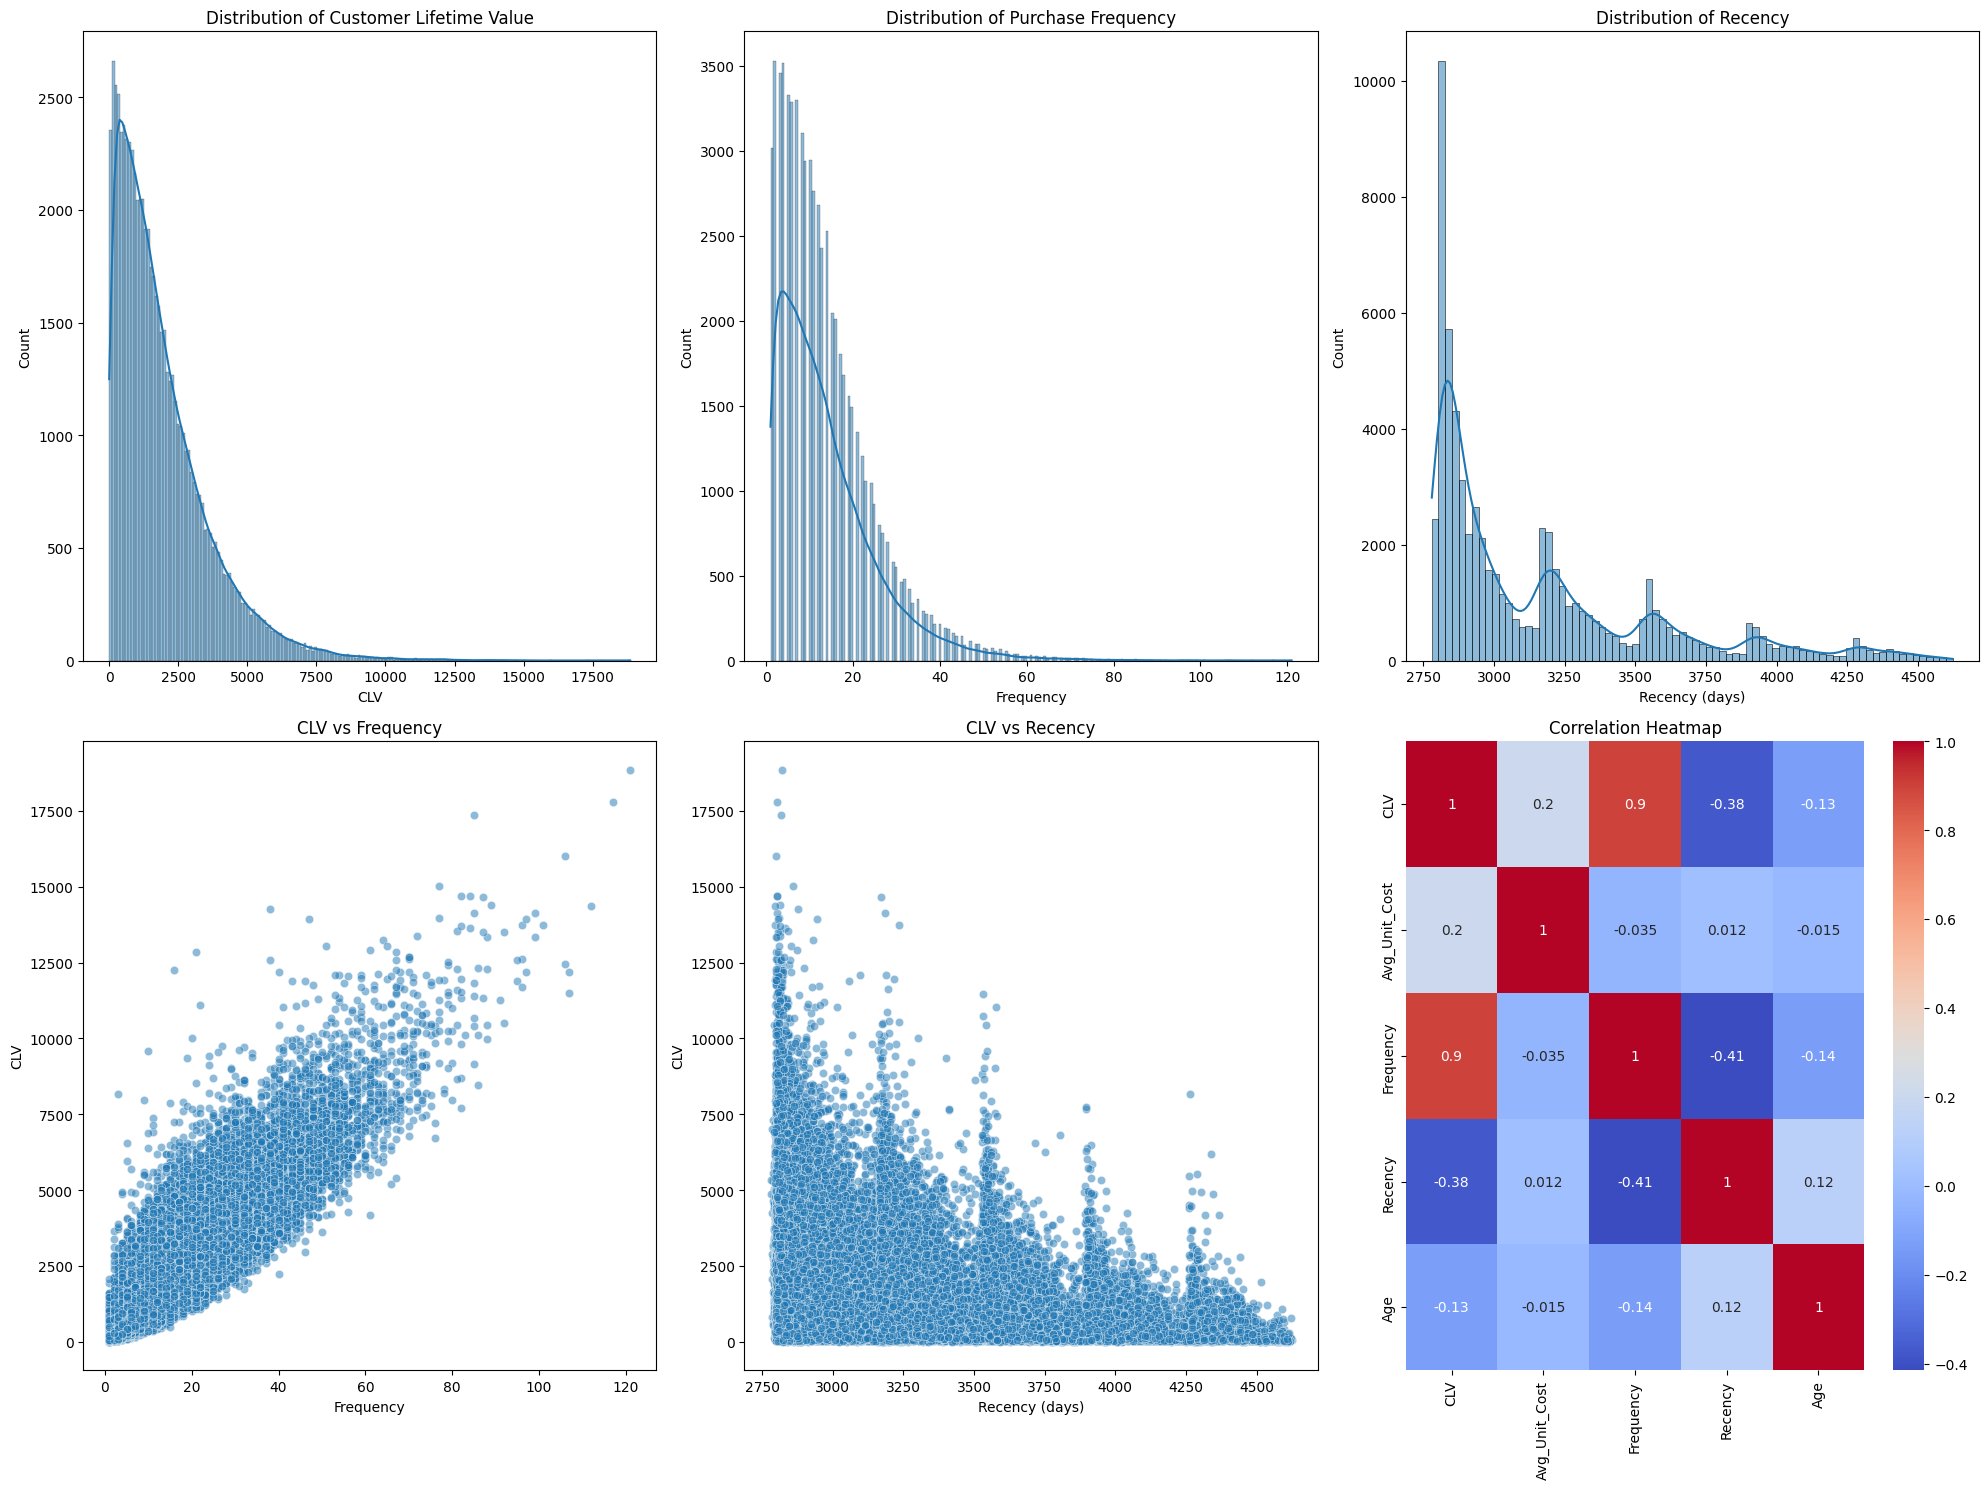

In [ ]:
visualize_key_features(df_aggr)

Before outlier handling:
                CLV  Avg_Unit_Cost     Frequency
count  67766.000000   67766.000000  67766.000000
mean    1922.265330      78.754069     13.759422
std     1706.364135      38.242742     11.256373
min        0.630000       0.500000      1.000000
25%      676.800000      57.357143      6.000000
50%     1469.470000      73.278604     11.000000
75%     2675.745000      92.343442     19.000000
max    18860.960000    1463.500000    121.000000

After outlier handling:
                CLV  Avg_Unit_Cost     Frequency
count  67766.000000   67766.000000  67766.000000
mean       7.096826      78.057104      2.407949
std        1.128287      33.101798      0.789568
min        0.488580      17.688333      0.693147
25%        6.518852      57.357143      1.945910
50%        7.293337      73.278604      2.484907
75%        7.892357      92.343442      2.995732
max        9.844902     214.350000      4.804021


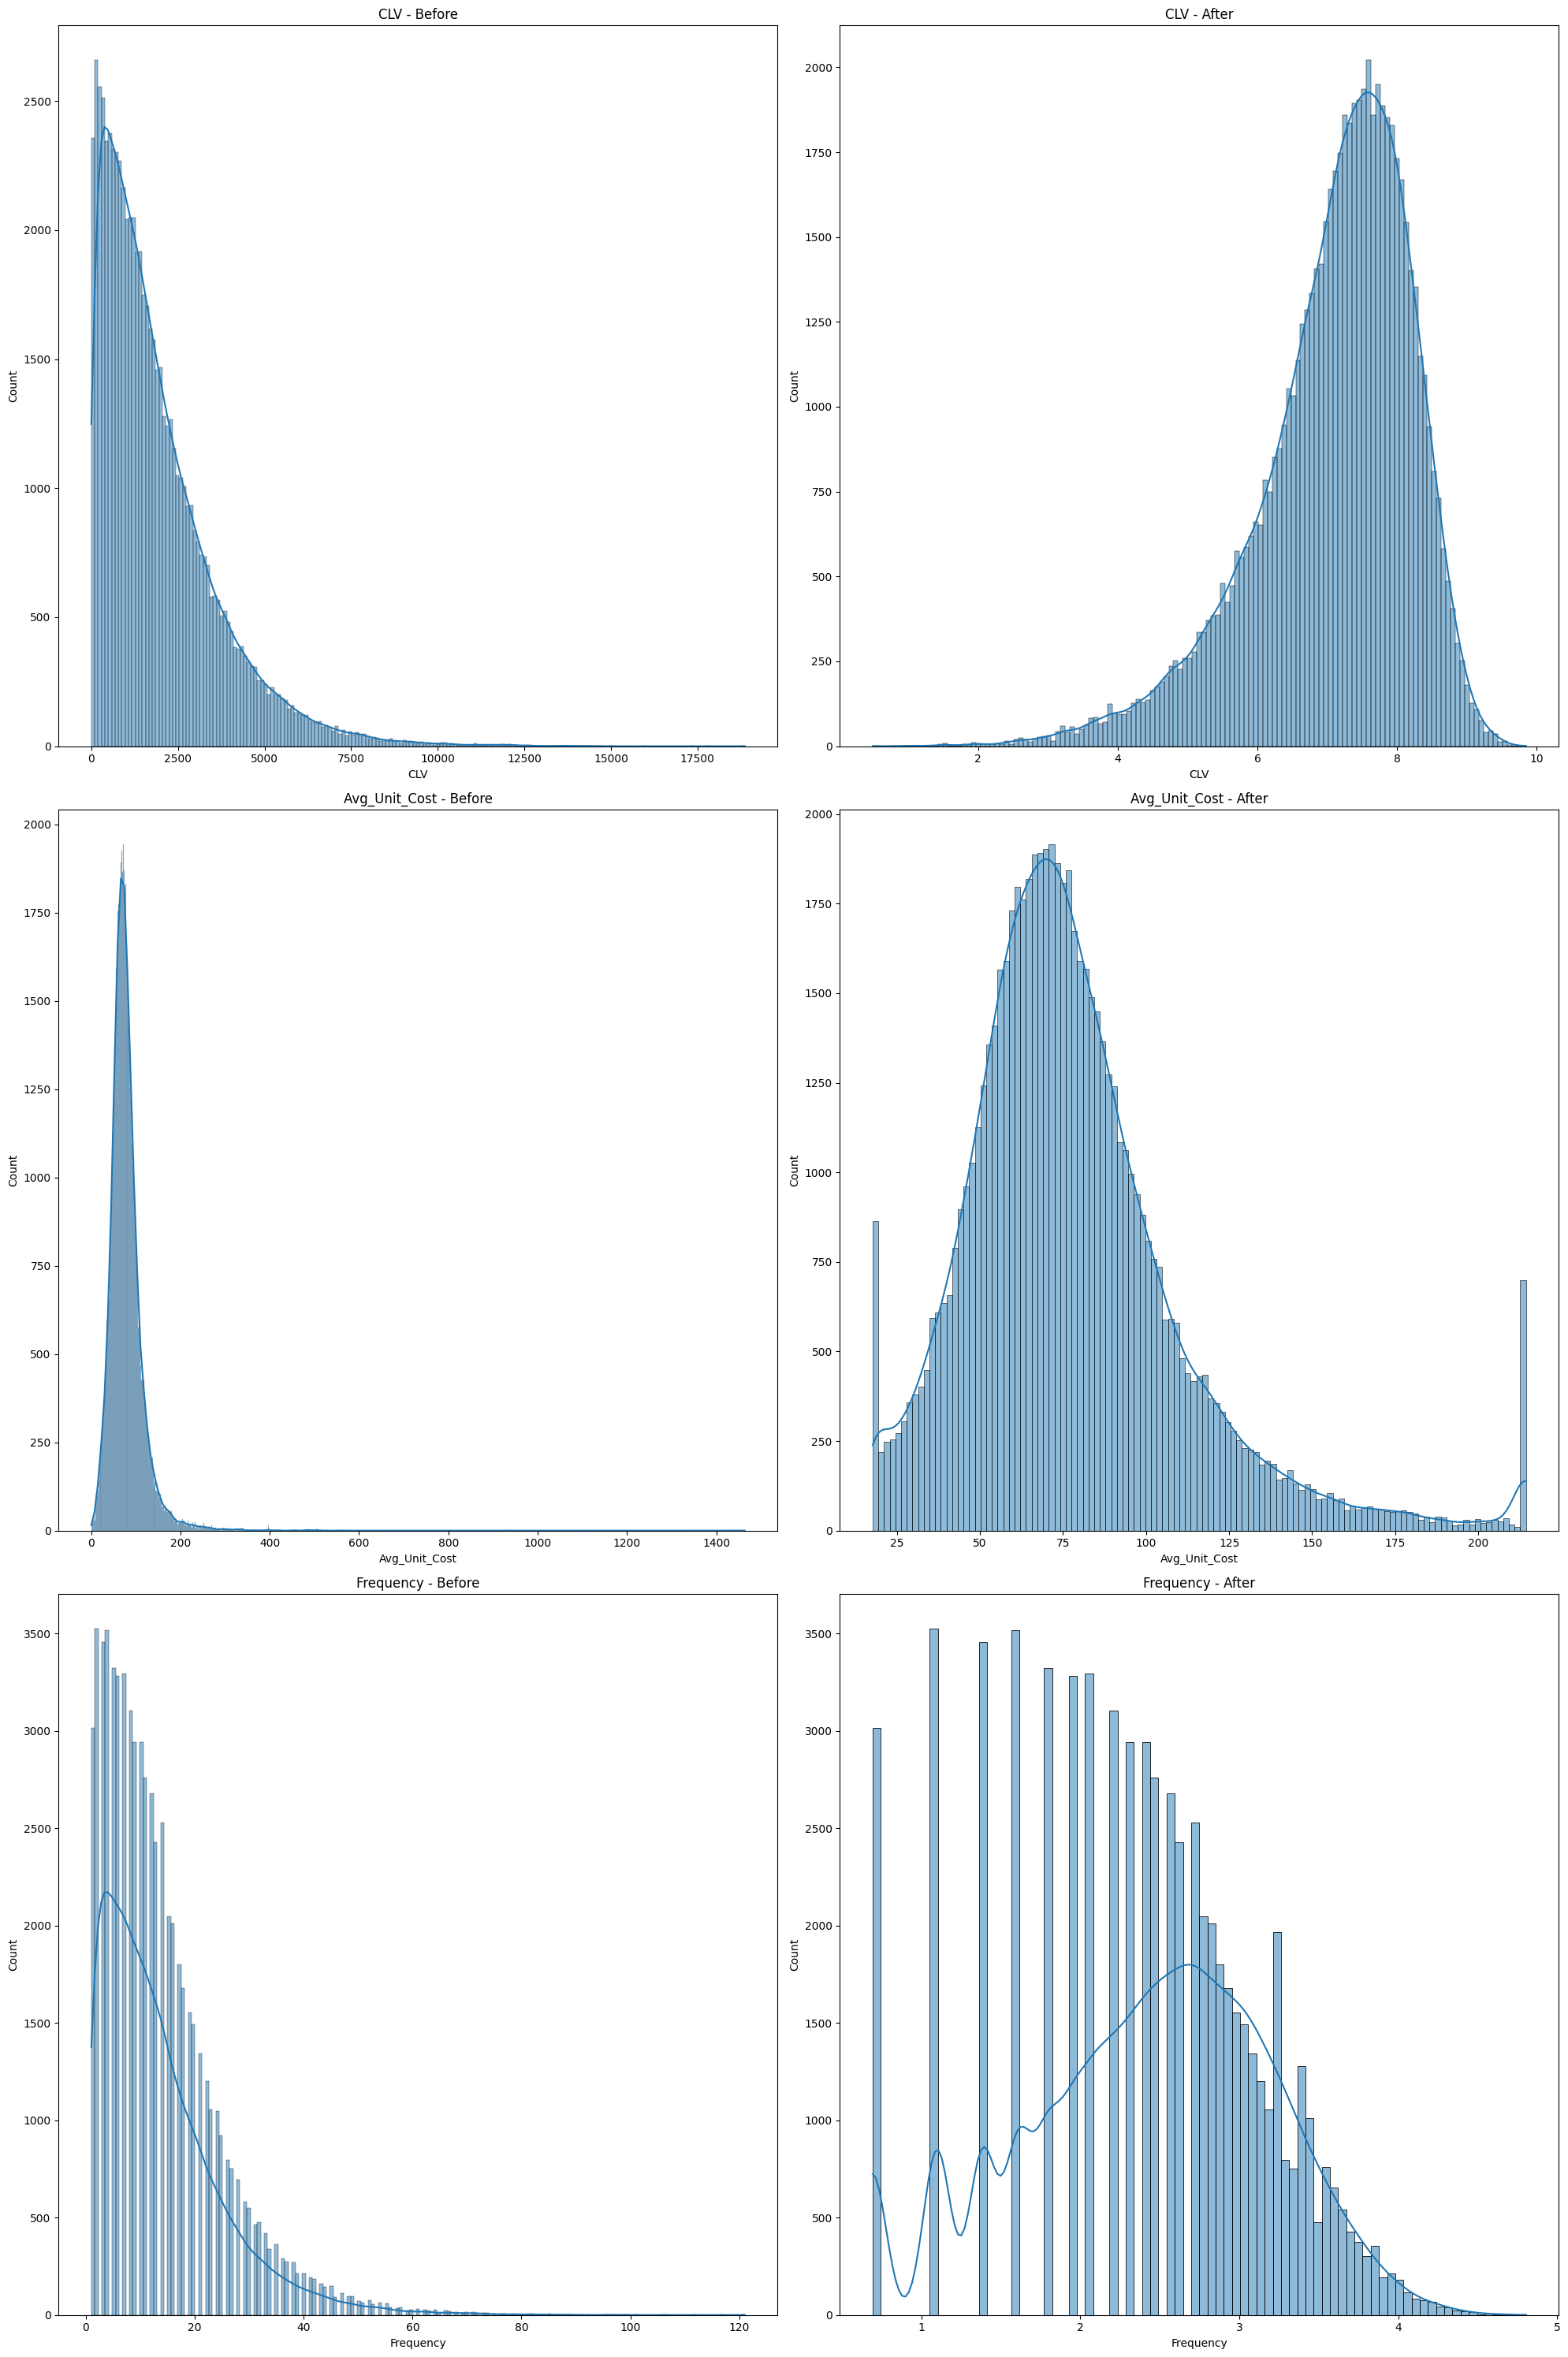

Column: CLV
Number of outliers: 2006
Percentage of outliers: 2.96%
-------------------------
Column: Avg_Unit_Cost
Number of outliers: 2810
Percentage of outliers: 4.15%
-------------------------
Column: Frequency
Number of outliers: 15
Percentage of outliers: 0.02%
-------------------------


In [ ]:
def handle_outliers_custom(df):
    df_cleaned = df.copy()

    # CLV: Log transform (often has a long-tail distribution)
    df_cleaned["CLV"] = np.log1p(df_cleaned["CLV"])

    # Avg_Unit_Cost: Winsorize (cap at 99th percentile to preserve some high-value purchases)
    df_cleaned["Avg_Unit_Cost"] = apply_winsorize(df_cleaned, "Avg_Unit_Cost", 0.01)

    # Frequency: Log transform (likely has a long-tail distribution)
    df_cleaned["Frequency"] = np.log1p(df_cleaned["Frequency"])

    return df_cleaned


# Apply the custom outlier handling
df_cleaned = handle_outliers_custom(df_aggr)

# Print summary statistics before and after outlier handling
print("Before outlier handling:")
print(df_aggr[["CLV", "Avg_Unit_Cost", "Frequency"]].describe())

print("\nAfter outlier handling:")
print(df_cleaned[["CLV", "Avg_Unit_Cost", "Frequency"]].describe())

# Visualize the distributions before and after outlier handling
fig, axes = plt.subplots(3, 2, figsize=(20, 30))
features = ["CLV", "Avg_Unit_Cost", "Frequency"]

for i, feature in enumerate(features):
    sns.histplot(df_aggr[feature], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{feature} - Before")

    sns.histplot(df_cleaned[feature], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{feature} - After")

plt.tight_layout()
plt.show()

# Print outliers after handling
print_outliers(df_cleaned, features)

Rationale for Outlier Handling Methods:

1. CLV (Customer Lifetime Value):

   Method: Log transform
   - CLV exhibits a long-tail distribution, with many customers having low to moderate values and a few having very high values.
   - Log transformation helps to compress the scale of high values while maintaining the order and relative differences between customers.
   - This method preserves the important distinctions between high-value and extremely high-value customers, which might be crucial for segmentation.
   - It makes the distribution more normal-like, which can improve the performance of clustering algorithms.

2. Avg_Unit_Cost:

   Method: Winsorize (capping at 99th percentile)

   - Average unit cost can have legitimate high values that represent luxury purchases or high-end products.
   - Winsorizing at the 99th percentile preserves most of the data's natural variation.
   - It caps only the most extreme values, which could be errors or highly unusual purchases.
   - This method retains the distinction of high-value purchases while mitigating the impact of extreme outliers on the clustering.

3. Frequency:

   Method: Log transform

   - Purchase frequency often follows a long-tail distribution, similar to CLV.
   - Some customers may make very frequent purchases, creating a right-skewed distribution.
   - Log transformation helps normalize this distribution, making the differences between low, medium, and high-frequency customers more distinguishable for clustering algorithms.
   - It reduces the impact of extremely high-frequency outliers without losing the information that some customers purchase much more frequently than others.

4. Recency:
   Left as is

   - Recency distribution is not normal and has a mix of short and long towers in a zig-zag pattern.
   - This unusual distribution might represent genuine patterns in customer behavior, such as:
     * Peaks that could correspond to regular sale periods or marketing campaigns
     * Multiple modes that might represent different customer segments (e.g., regular shoppers vs. occasional buyers)
   - Applying a transformation or outlier removal method could obscure these potentially important patterns in customer behavior.
   - For clustering purposes, preserving this unique distribution might help in identifying distinct customer segments based on their recency patterns.

In [ ]:
df_aggr = df_cleaned

### Pipeline definitions

In [ ]:
def create_preprocessor(df):
    # Define features, excluding 'Customer ID'
    features = [col for col in df.columns if col != "Customer ID"]

    # Create the preprocessor
    preprocessor = ColumnTransformer(
        transformers=[("num", StandardScaler(), features)],
        remainder="passthrough",  # This will keep 'Customer ID' untouched
    )

    return preprocessor, features

In [ ]:
def preprocess_data(df, preprocessor):
    # Store the original 'Customer ID' column
    customer_id = df["Customer ID"]

    # Fit the preprocessor and transform the data
    X_preprocessed = preprocessor.fit_transform(df)

    # Get the feature names from the preprocessor
    feature_names = preprocessor.named_transformers_["num"].get_feature_names_out(
        input_features=[col for col in df.columns if col != "Customer ID"]
    )

    # Convert back to DataFrame
    df_preprocessed = pd.DataFrame(
        X_preprocessed,
        columns=list(feature_names)
        + ["Customer ID"],  # 'Customer ID' will be the last column
        index=df.index,
    )

    # Replace the 'Customer ID' column with the original one
    df_preprocessed["Customer ID"] = customer_id

    return df_preprocessed

In [ ]:
def inverse_transform(preprocessor, X, features):
    # Get the StandardScaler from the ColumnTransformer
    scaler = preprocessor.named_transformers_["num"]

    # Inverse transform the data
    X_inv = scaler.inverse_transform(X)

    # Create a DataFrame with the original feature names
    df_inv = pd.DataFrame(X_inv, columns=features)

    return df_inv

In [ ]:
# creating preprocessor and features
preprocessor, features = create_preprocessor(df_aggr)
df_preprocessed = preprocess_data(df_aggr, preprocessor)

### K-Means

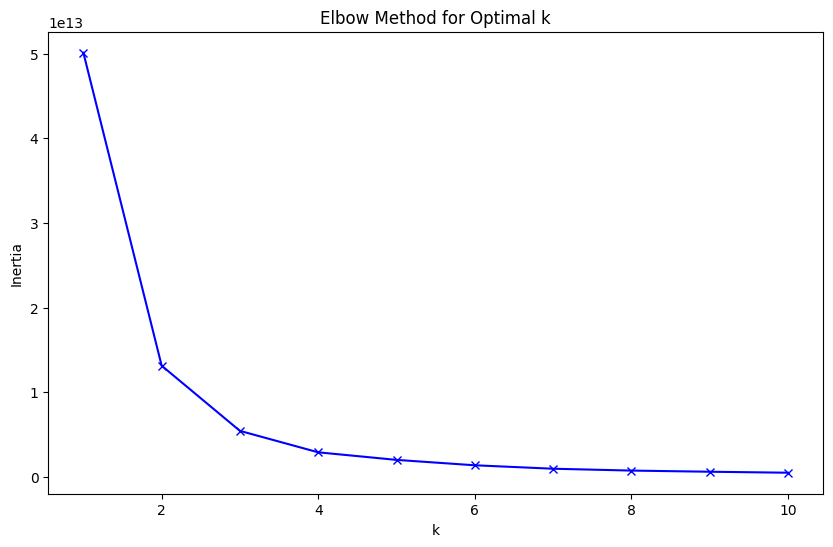

Percentage decrease from k=1 to k=2: -73.82%
Percentage decrease from k=2 to k=3: -58.74%
Percentage decrease from k=3 to k=4: -46.83%
Percentage decrease from k=4 to k=5: -31.10%
Percentage decrease from k=5 to k=6: -32.14%
Percentage decrease from k=6 to k=7: -30.23%
Percentage decrease from k=7 to k=8: -23.34%
Percentage decrease from k=8 to k=9: -18.97%
Percentage decrease from k=9 to k=10: -20.03%


In [ ]:
# Elbow Method for Optimal k
inertias = []
k_range = range(1, 11)
preprocessor, _ = create_preprocessor(df_aggr)
for k in k_range:
    kmeans_pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
        ]
    )

    # Fit the pipeline
    kmeans_pipeline.fit(df_aggr)

    # Get the inertia
    inertias.append(kmeans_pipeline.named_steps["kmeans"].inertia_)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, "bx-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Calculate and print the percentage decrease in inertia
inertia_decreases = np.diff(inertias) / np.array(inertias[:-1]) * 100
for k, decrease in zip(k_range[1:], inertia_decreases):
    print(f"Percentage decrease from k={k-1} to k={k}: {decrease:.2f}%")

The largest drops in inertia occur from k=1 to k=2 (-73.82%) and k=2 to k=3 (-58.74%).
After k=3, the percentage decreases become notably smaller.
The curve visibly starts to level off after k=3.

Given this perspective, k=3 does indeed appear to be a strong candidate for the elbow point. It captures a significant amount of variance reduction while avoiding unnecessary complexity. This choice balances model simplicity with explanatory power, which aligns well with the elbow method's goal.

In [ ]:
def perform_kmeans_clustering(df, preprocessor, features, n_clusters):
    # Separate features and Customer ID
    X = df[features]

    kmeans_pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("kmeans", KMeans(n_clusters=n_clusters, random_state=42, n_init=10)),
        ]
    )

    # Fit the pipeline
    kmeans_pipeline.fit(X)

    # Get cluster labels
    cluster_labels = kmeans_pipeline.named_steps["kmeans"].labels_

    # Create a DataFrame with Customer ID and cluster label
    result_df = pd.DataFrame(
        {"Customer ID": df["Customer ID"], "Cluster": cluster_labels}
    )

    # Calculate silhouette score

    silhouette_avg = silhouette_score(
        kmeans_pipeline.transform(df_preprocessed[features]), cluster_labels
    )
    # Extract centroids
    centroids = kmeans_pipeline.named_steps["kmeans"].cluster_centers_

    # Perform PCA to reduce dimensions for visualization
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(X)

    # Create a DataFrame with PCA results
    df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])
    df_pca["cluster"] = cluster_labels

    # Plotting the clusters
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Scatter plot
    sns.scatterplot(
        data=df_pca, x="PC1", y="PC2", hue="cluster", palette="deep", ax=ax1
    )
    centroids_pca = pca.transform(centroids)
    ax1.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        s=200,
        marker="X",
        c="red",
        edgecolor="black",
        label="Centroids",
    )
    ax1.set_title(f"K-means Clustering Results (PCA) with k={n_clusters}")
    ax1.set_xlabel("Principal Component 1")
    ax1.set_ylabel("Principal Component 2")
    ax1.legend()

    # Silhouette plot
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.get_cmap("Spectral")(float(i) / n_clusters)
        ax2.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax2.set_title("The silhouette plot for the various clusters.")
    ax2.set_xlabel("The silhouette coefficient values")
    ax2.set_ylabel("Cluster label")
    ax2.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax2.set_yticks([])  # Clear the yaxis labels / ticks
    ax2.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

    # Calculate cluster centroids in original feature space
    centroids_original = inverse_transform(preprocessor, centroids, features)

    # Calculate cluster means
    df_with_clusters = df.copy()
    df_with_clusters["Cluster"] = cluster_labels
    cluster_means = df_with_clusters.groupby("Cluster")[features].mean()

    # centroids and cluster means
    centroid_df = pd.DataFrame(centroids_original, columns=features)

    # Calculate feature importance
    feature_importance = calculate_feature_importance(df_with_clusters, features)

    return result_df, kmeans_pipeline, centroid_df, cluster_means, feature_importance


def calculate_feature_importance(df, features):
    # Calculate the overall mean and standard deviation
    overall_mean = df[features].mean()
    overall_std = df[features].std()

    # Calculate the mean for each cluster
    cluster_means = df.groupby("Cluster")[features].mean()

    # Calculate the absolute difference from the overall mean
    diff_from_mean = abs(cluster_means - overall_mean)

    # Normalize by standard deviation
    importance = diff_from_mean / overall_std

    # Calculate the average importance across clusters
    avg_importance = importance.mean()

    # Sort features by importance
    sorted_importance = avg_importance.sort_values(ascending=False)

    return sorted_importance


def inverse_transform(preprocessor, X, features):
    # Get the scaler from the preprocessor
    scaler = preprocessor.named_transformers_["num"]

    # Inverse transform the data
    X_original = scaler.inverse_transform(X)

    return X_original

Running K-Means with 3 clusters...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
<ipython-input-55-01ee4c6be6d3>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / n_clusters)


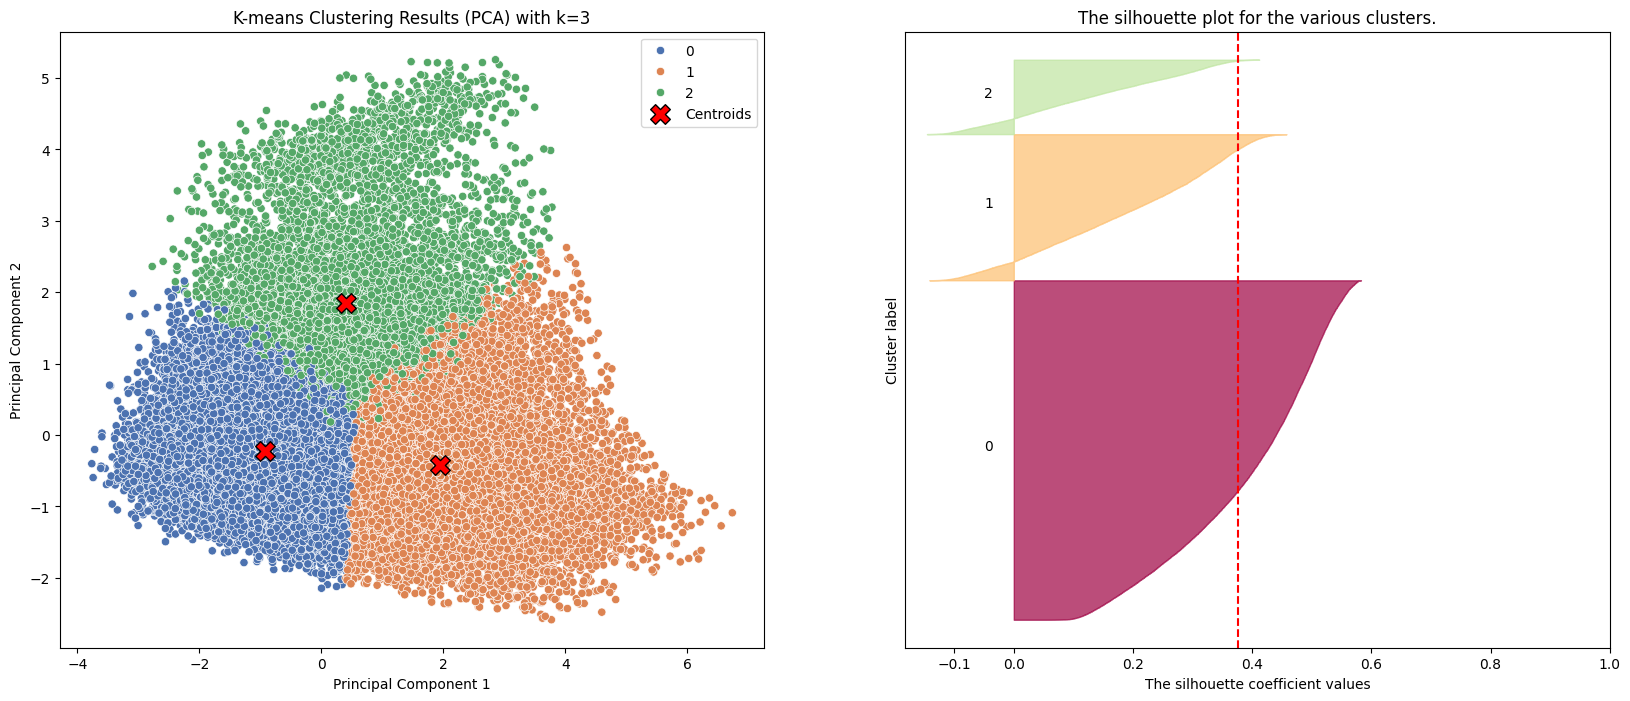

Centroids:
        CLV  Avg_Unit_Cost  Frequency   Recency       Age
0  0.539367      -0.076482   0.617060 -0.456806 -0.155821
1 -1.236749      -0.714965  -1.067532  0.826660  0.297589
2 -0.036184       1.742293  -0.719149  0.461416  0.126938

Cluster Means:
              CLV  Avg_Unit_Cost  Frequency   Recency       Age
Cluster                                                        
0        0.539920      -0.075371   0.617188 -0.456701 -0.156203
1       -1.235402      -0.714203  -1.066488  0.824574  0.296922
2       -0.037530       1.745876  -0.721585  0.464445  0.129606

Feature Importance:
Avg_Unit_Cost    0.845144
Frequency        0.801748
CLV              0.604279
Recency          0.581902
Age              0.194242
dtype: float64
Silhouette Score for 3 clusters: 0.37666616529262
   Customer ID  Cluster
0            1        0
1            3        0
2            4        1
3            5        0
4            6        0


Running K-Means with 4 clusters...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
<ipython-input-55-01ee4c6be6d3>:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = plt.cm.get_cmap("Spectral")(float(i) / n_clusters)


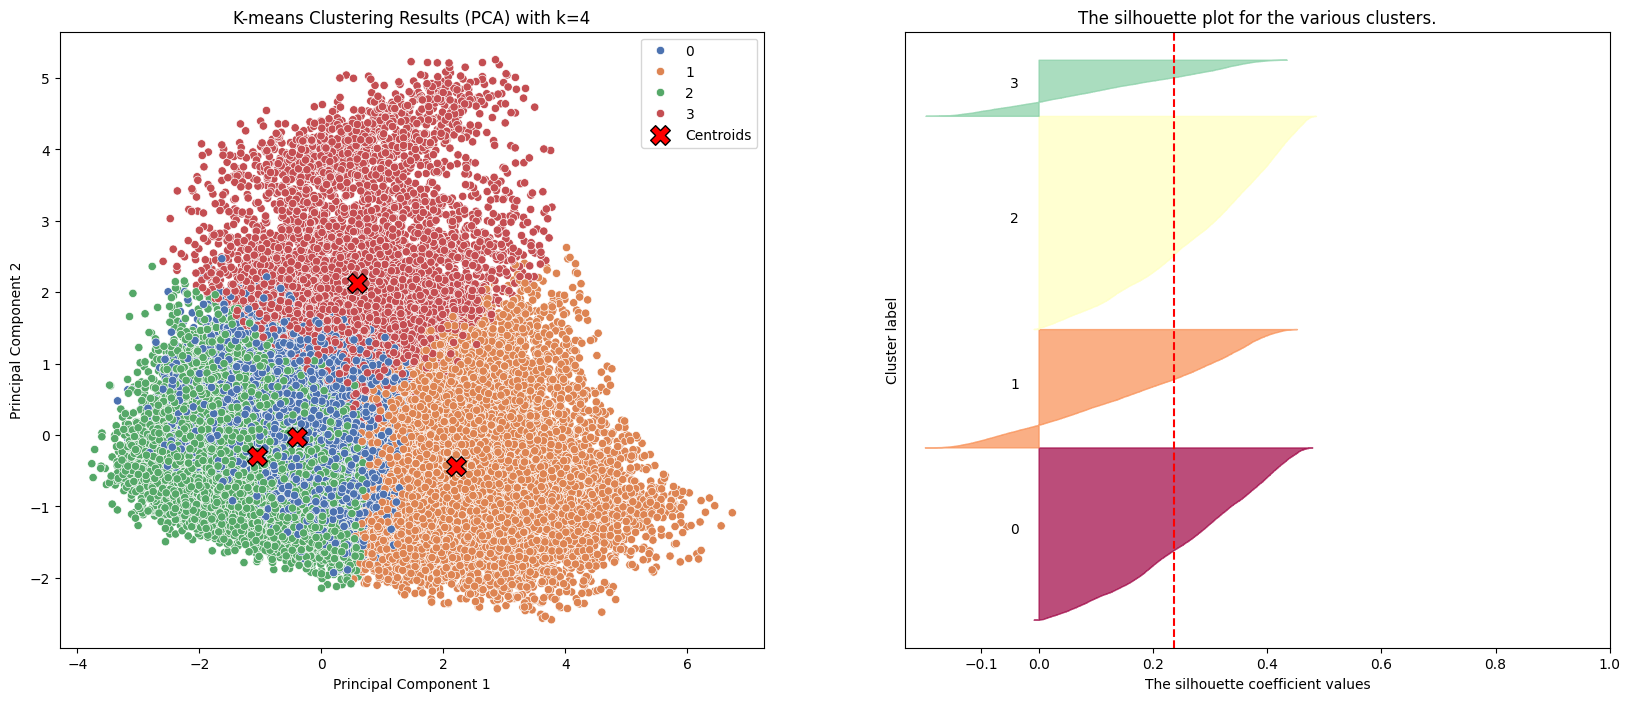

Centroids:
        CLV  Avg_Unit_Cost  Frequency   Recency       Age
0  0.317128      -0.103103   0.348056 -0.360785  0.866769
1 -1.406955      -0.757066  -1.210978  1.016290  0.198776
2  0.558042      -0.025577   0.624753 -0.434479 -0.824441
3 -0.126554       2.007384  -0.887053  0.614540  0.048343

Cluster Means:
              CLV  Avg_Unit_Cost  Frequency   Recency       Age
Cluster                                                        
0        0.316011      -0.102985   0.346595 -0.360949  0.867310
1       -1.406476      -0.756310  -1.210958  1.017614  0.198430
2        0.558363      -0.025959   0.625456 -0.434426 -0.823597
3       -0.125575       2.009504  -0.886574  0.612731  0.046774

Feature Importance:
Frequency        0.767390
Avg_Unit_Cost    0.723684
Recency          0.606426
CLV              0.601602
Age              0.484024
dtype: float64
Silhouette Score for 4 clusters: 0.23731815975566664
   Customer ID  Cluster
0            1        0
1            3        2
2       

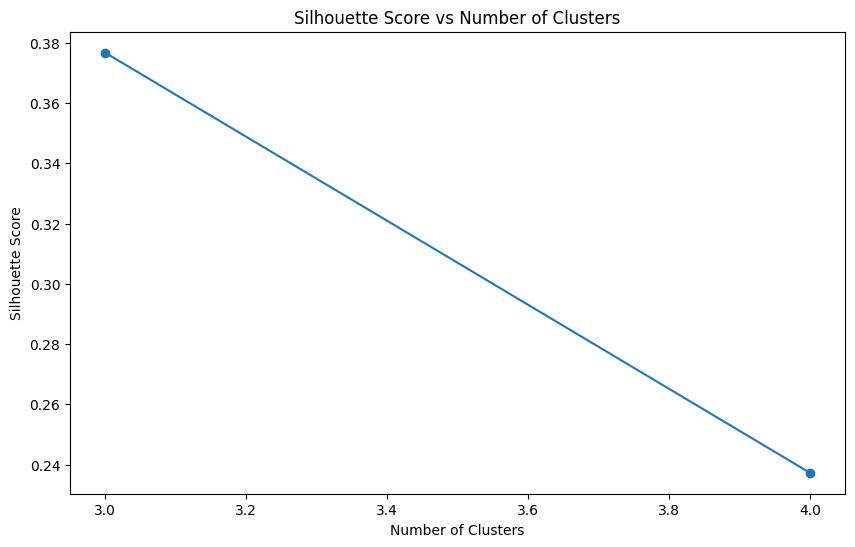

In [ ]:
# Define the range of cluster numbers to try
cluster_range = range(3, 5)  # This will try 3 and 4

# Initialize dictionaries to store results
clustering_results = {}
pipelines = {}
silhouette_scores = {}

# Loop through different numbers of clusters
for n_clusters in cluster_range:
    print(f"Running K-Means with {n_clusters} clusters...")

    # Perform clustering
    kmeans_results, kmeans_pipeline, centroids, cluster_means, feature_importance = (
        perform_kmeans_clustering(
            df_preprocessed, preprocessor, features, n_clusters=n_clusters
        )
    )

    # Store results
    clustering_results[n_clusters] = {
        "results": kmeans_results,
        "centroids": centroids,
        "cluster_means": cluster_means,
        "feature_importance": feature_importance,
    }
    pipelines[n_clusters] = kmeans_pipeline

    print("Centroids:")
    print(centroids)
    print("\nCluster Means:")
    print(cluster_means)
    print("\nFeature Importance:")
    print(feature_importance)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(
        kmeans_pipeline.transform(df_preprocessed[features]), kmeans_results["Cluster"]
    )
    silhouette_scores[n_clusters] = silhouette_avg

    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg}")
    print(kmeans_results.head())
    print("\n")

# Print summary of results
print("\nSummary of Clustering Results:")
for n_clusters, results in clustering_results.items():
    print(f"\nClustering with {n_clusters} clusters:")
    print(results["results"]["Cluster"].value_counts().sort_index())
    print(f"Silhouette Score: {silhouette_scores[n_clusters]}")


# Visualize silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

The highest silhouette score is for 3 clusters, indicating better cluster separation and cohesion.

Cluster Interpretations for k=3:

Cluster 0 (60.7%) likely represents your average customers with moderate frequency, recency, and CLV.

Cluster 1 (26.1%) might represent high-value customers with high frequency, recency, and CLV.

Cluster 2 (13.3%) could represent low-value or at-risk customers with low frequency, recency, and CLV.


The 4-cluster solution, while providing more granular segmentation, shows more overlap between groups. This could make it harder to develop distinct strategies for each segment.

### Hierarchical Clustering

In [ ]:
def perform_hierarchical_clustering_and_visualize(
    df, preprocessor, features, n_clusters=3
):
    # Separate features and Customer ID
    X = df[features]
    customer_ids = df["Customer ID"]

    # Perform PCA
    pca = PCA()
    df_pca = pca.fit_transform(X)

    # Calculate explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42, n_iter=250)
    df_tsne = tsne.fit_transform(X)

    # Perform clustering with 3 clusters
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(X, labels)

    # Create a DataFrame with Customer ID and cluster label
    result_df = pd.DataFrame({"Customer ID": customer_ids, "Cluster": labels})

    # Merge with original data
    clustered_df = pd.concat([df, result_df["Cluster"]], axis=1)

    # Plotting
    fig = plt.figure(figsize=(20, 20))

    # 1. Scatter plot with PCA
    ax1 = fig.add_subplot(321)
    scatter = ax1.scatter(
        df_pca[:, 0], df_pca[:, 1], c=labels, cmap="viridis", alpha=0.5
    )
    ax1.set_title(f"PCA of Clusters (n_clusters={n_clusters})")
    ax1.set_xlabel("First Principal Component")
    ax1.set_ylabel("Second Principal Component")
    plt.colorbar(scatter)

    # 2. Scatter plot with t-SNE
    ax2 = fig.add_subplot(322)
    scatter = ax2.scatter(
        df_tsne[:, 0], df_tsne[:, 1], c=labels, cmap="viridis", alpha=0.5
    )
    ax2.set_title(f"t-SNE of Clusters (n_clusters={n_clusters})")
    ax2.set_xlabel("t-SNE feature 1")
    ax2.set_ylabel("t-SNE feature 2")
    plt.colorbar(scatter)

    # 3. Dendrogram
    ax3 = fig.add_subplot(323)
    linkage_matrix = linkage(X, method="ward")
    dendrogram(
        linkage_matrix,
        truncate_mode="lastp",
        p=10,
        leaf_rotation=90,
        leaf_font_size=8,
        ax=ax3,
    )
    ax3.set_title("Dendrogram")
    ax3.set_xlabel("Sample Index")
    ax3.set_ylabel("Distance")

    # 4. Silhouette score
    ax4 = fig.add_subplot(324)
    ax4.text(
        0.5,
        0.5,
        f"Silhouette Score: {silhouette_avg:.4f}",
        horizontalalignment="center",
        verticalalignment="center",
    )
    ax4.axis("off")

    # 5. PCA explained variance ratio
    ax5 = fig.add_subplot(325)
    ax5.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
    ax5.set_title("PCA Explained Variance Ratio")
    ax5.set_xlabel("Principal Component")
    ax5.set_ylabel("Explained Variance Ratio")

    # 6. Cluster sizes
    ax6 = fig.add_subplot(326)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    ax6.bar(cluster_sizes.index, cluster_sizes.values)
    ax6.set_title(f"Cluster Sizes (n_clusters={n_clusters})")
    ax6.set_xlabel("Cluster")
    ax6.set_ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

    # Feature boxplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        sns.boxplot(x="Cluster", y=feature, data=clustered_df, ax=axes[i])
        axes[i].set_title(f"{feature} by Cluster")

    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"Number of clusters: {n_clusters}")
    print(f"Silhouette score: {silhouette_avg:.4f}")
    print(f"Cluster sizes: {cluster_sizes.tolist()}")

    return labels, result_df

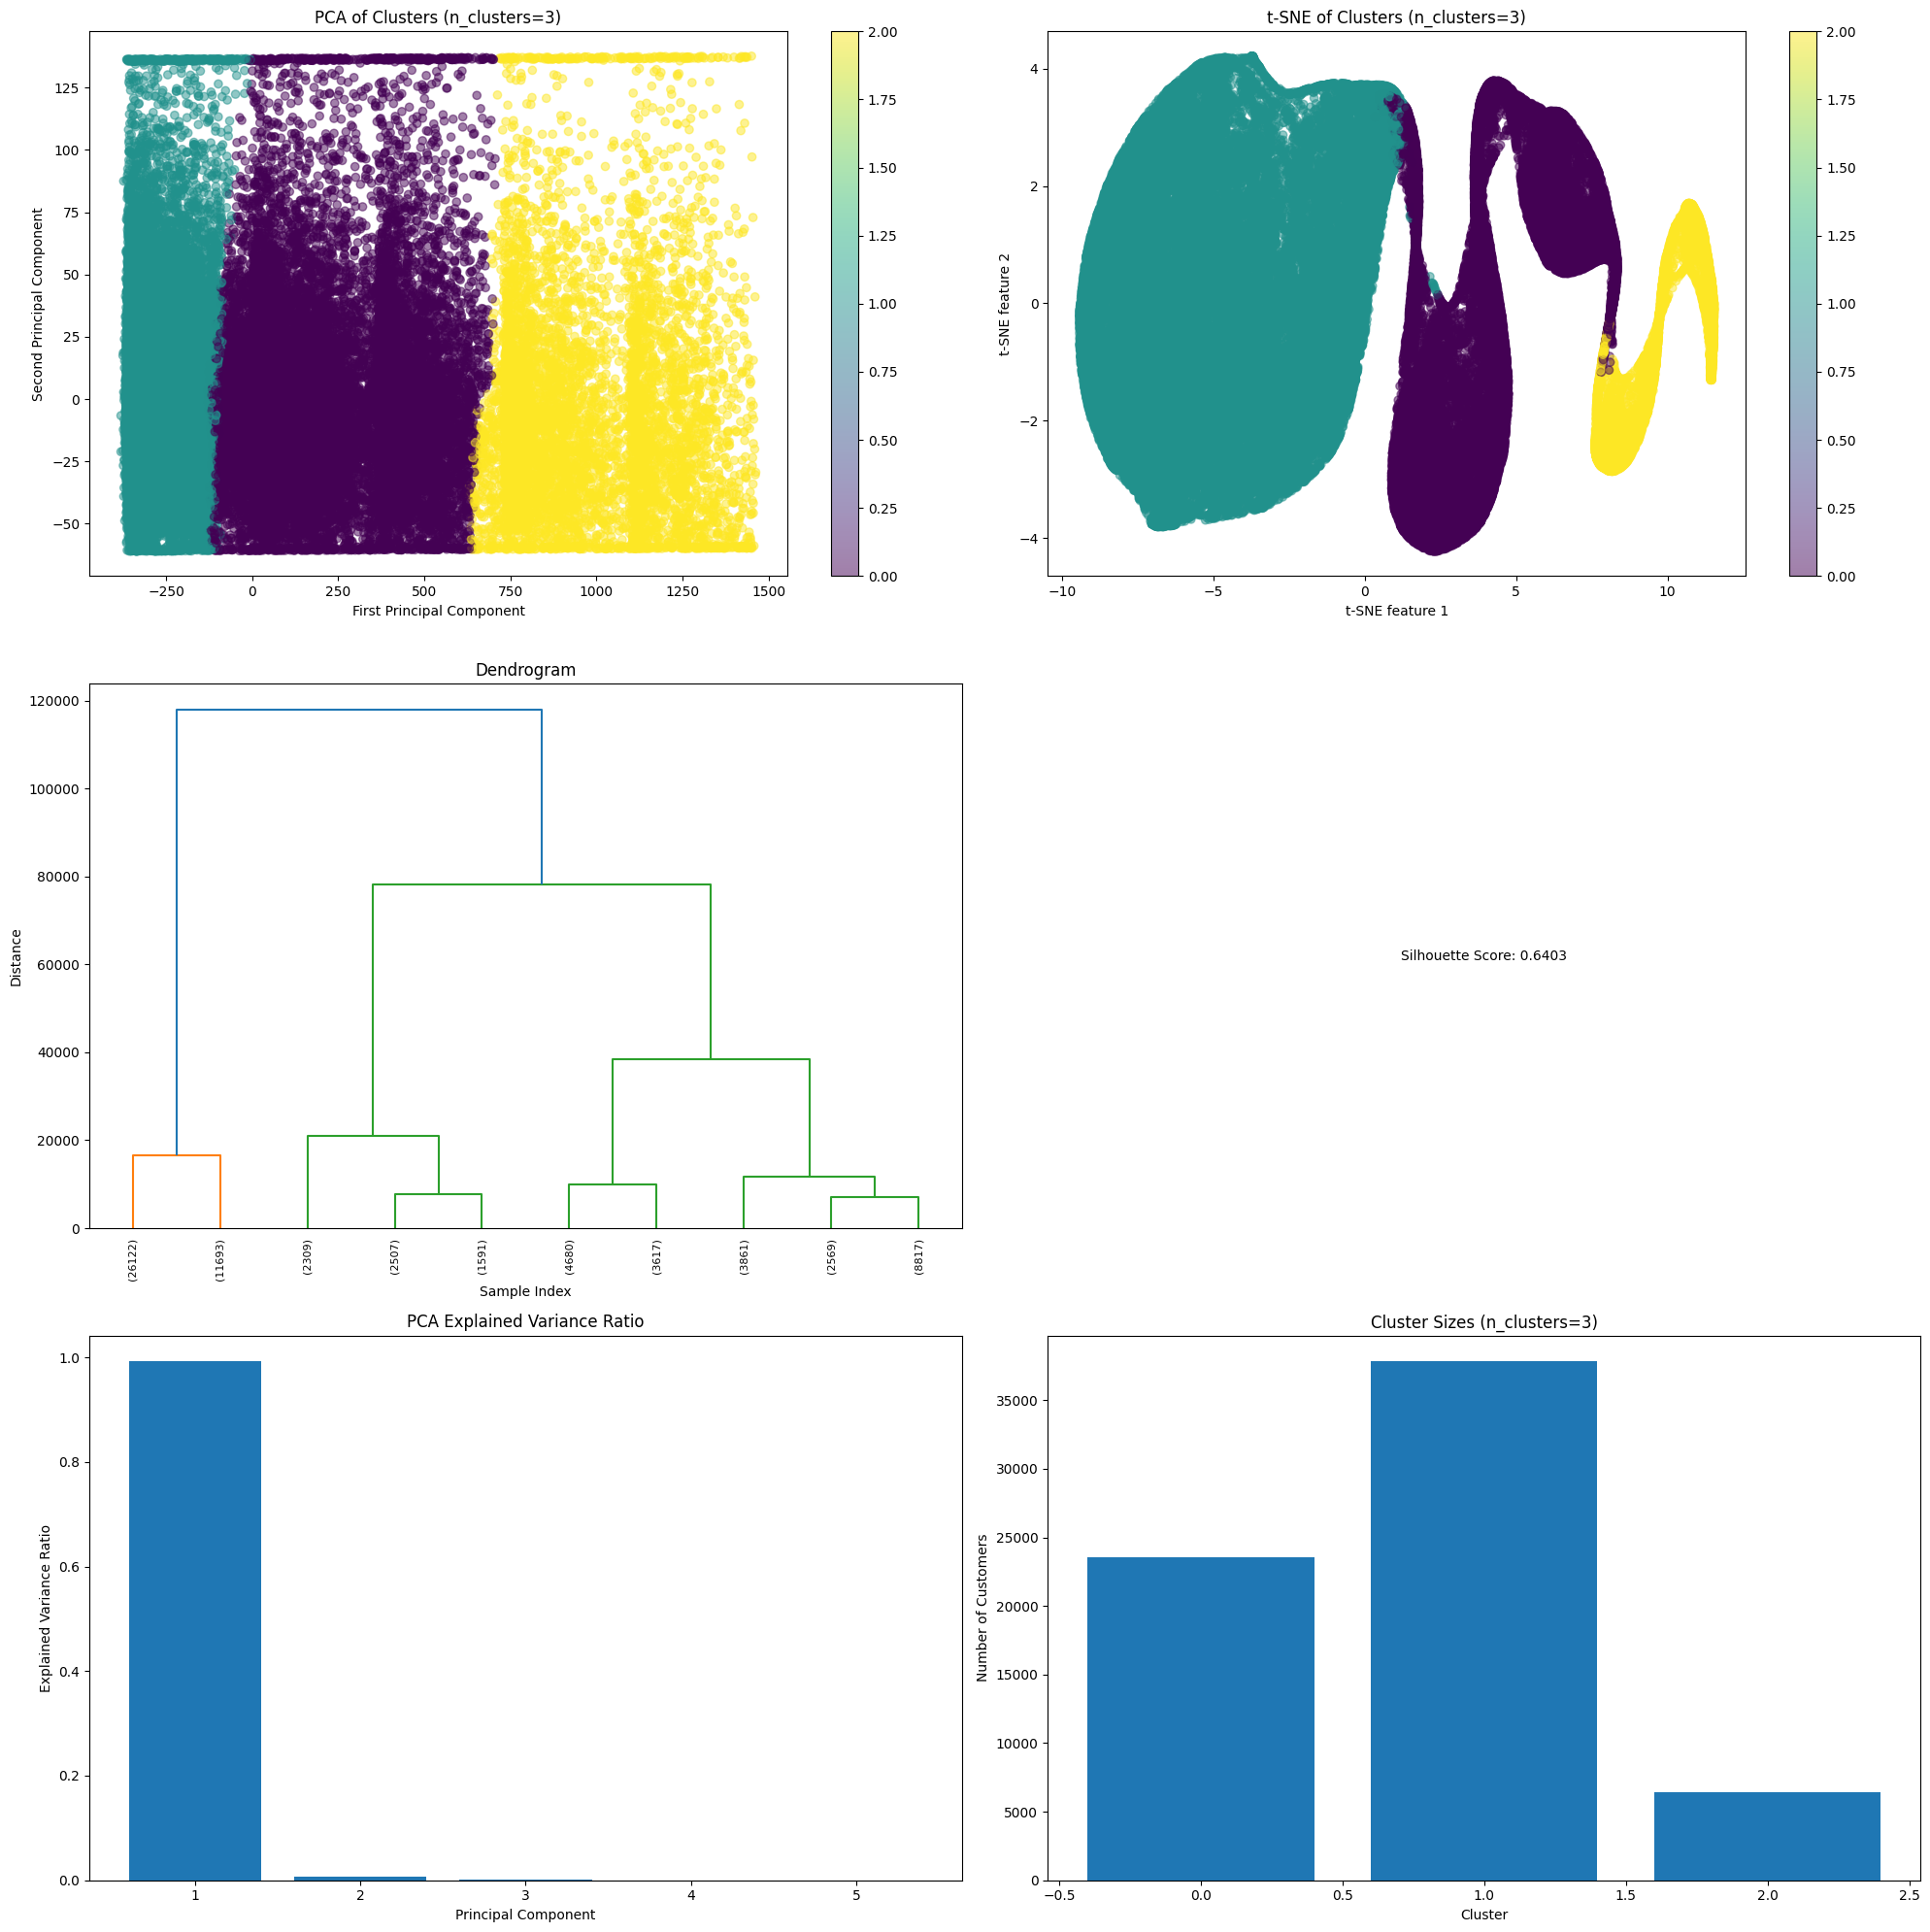

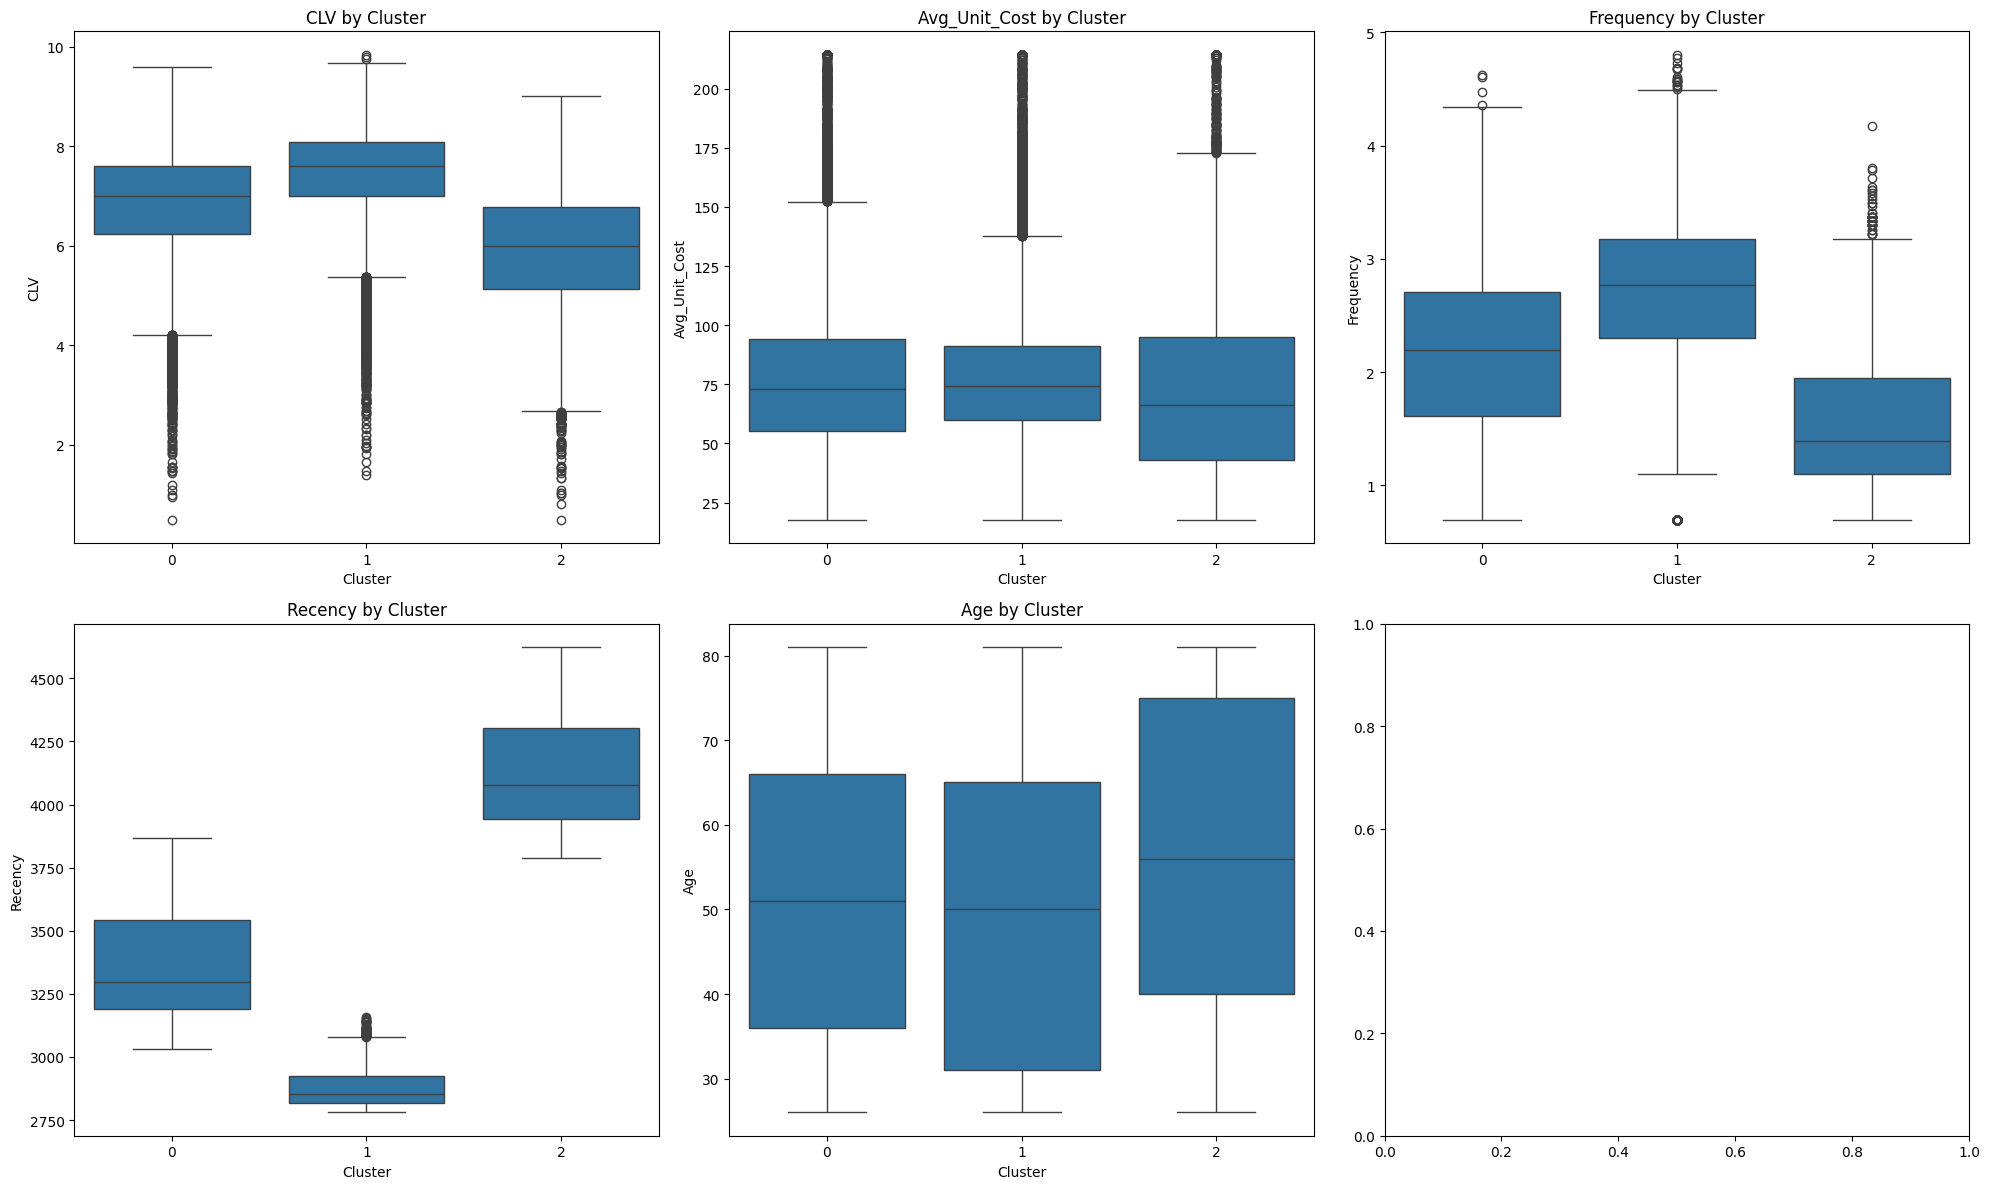

Number of clusters: 3
Silhouette score: 0.6403
Cluster sizes: [23544, 37815, 6407]


In [ ]:
# Hierarchical clustering for 3 clusters

labels, result_df = perform_hierarchical_clustering_and_visualize(
    df_aggr, preprocessor, features, n_clusters=3
)

The dendrogram shows the hierarchical structure of the clusters. We can see three main branches, which aligns with the chosen number of clusters (3). The height of the branches indicates the distance between clusters, with the highest split occurring at a distance of about 120,000, suggesting a clear separation between the main clusters.


The t-SNE plot shows three distinct clusters:
A large teal cluster on the left
A purple cluster in the center
A smaller yellow cluster on the right
These clusters are well-separated, which supports the high silhouette score of 0.6403.


The PCA plot also shows three distinct clusters, color-coded similarly to the t-SNE plot. This visualization provides a different perspective on the data, showing how the clusters are separated in terms of the first two principal components.

The hierarchical clustering results show a clearer separation between clusters compared to the previous K-means results, as evidenced by the higher silhouette score (0.6403 vs 0.377 for 3 clusters in K-means).

#### Reflect

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

In our customer segmentation analysis, we employed hierarchical clustering as a complementary approach to K-means, aiming to uncover natural groupings in our customer base. After identifying the outliers we have applied the appropriate statistical methods to handle them, and scaled the data before clustering. Utilised the Pipeline method of efficiency running column transformers.

We explored both 3-cluster and 4-cluster solutions, utilising silhouette scores, cluster visualisations, and dendrograms to evaluate cluster quality and interpretability. The silhouette scores suggested that the 3-cluster solution provided slightly better-defined segments. However, we critically examined the cluster visualisations to ensure that this statistical preference aligned with meaningful and actionable customer segments.

The dendrograms offered insights into the hierarchical structure of our customer base, helping us understand how segments are nested and related. By combining these quantitative metrics with qualitative interpretation of cluster characteristics, we aimed to derive a segmentation strategy that was both statistically sound and business-relevant, demonstrating a balanced approach to data-driven decision making.

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].